# Imports

In [12]:
import sys
from pathlib import Path

current_dir = Path.cwd()
if current_dir.name == "notebooks":
    ROOT = current_dir.parent
else:
    ROOT = current_dir

if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from mpl_toolkits import mplot3d

from src.implied_vol import ImpliedVolSurface
from src.utils import get_spot, year_fraction

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)

# SPY Spot and Option Expiries

In [13]:
ticker = "SPY"
S = get_spot(ticker)
print(f"{ticker} spot price:", S)

import yfinance as yf
from datetime import datetime, timedelta
t = yf.Ticker(ticker)
all_expiries = t.options

from datetime import datetime
today = datetime.today().date()
min_date = today + timedelta(days=7)

future_expiries = []
for exp in all_expiries:
    exp_date = datetime.strptime(str(exp), '%Y-%m-%d').date()
    if exp_date >= min_date:
        future_expiries.append(exp)

expiries = future_expiries[:4]  # nearest 4 future expiries
print(f"Nearest 4 FUTURE expiries (min 7 days out):", expiries)

if len(expiries) == 0:
    print("ERROR: No future expiries available!")

SPY spot price: 754.8300170898438
Nearest 4 FUTURE expiries (min 7 days out): ['2026-06-22', '2026-06-23', '2026-06-24', '2026-06-25']


# Implied Volatility Surface

In [14]:
r = 0.03
iv_surface = ImpliedVolSurface(ticker, expiry_dates=expiries, rate=r)
surface_df = iv_surface.build_surface()

print(f"Surface shape: {surface_df.shape}")
print(f"Columns: {surface_df.columns.tolist()}")
surface_df.head()

Surface shape: (771, 10)
Columns: ['expiry', 'ttm', 'strike', 'moneyness', 'iv', 'option_type', 'lastPrice', 'bid', 'ask', 'volume']


,expiry,ttm,strike,moneyness,iv,option_type,lastPrice,bid,ask,volume
0,2026-06-22,0.02381,650.0,0.861121,0.090838,call,82.00,102.94,106.34,NaN
1,2026-06-22,0.02381,680.0,0.900865,0.409568,call,76.22,72.98,76.37,1.0
2,2026-06-22,0.02381,685.0,0.907489,0.080278,call,46.64,67.98,71.40,1.0
3,2026-06-22,0.02381,690.0,0.914113,0.061876,call,38.07,62.98,66.38,NaN
4,2026-06-22,0.02381,695.0,0.920737,0.047779,call,44.71,58.00,61.39,NaN


# Filter to Liquid Options

In [15]:
import importlib
import src.implied_vol
importlib.reload(src.implied_vol)

from src.implied_vol import ImpliedVolSurface

iv_surface = ImpliedVolSurface(ticker, expiry_dates=expiries, rate=r)
surface_df = iv_surface.build_surface()

print("Columns after rebuild:", surface_df.columns.tolist())
print(surface_df.head())

Columns after rebuild: ['expiry', 'ttm', 'strike', 'moneyness', 'iv', 'option_type', 'lastPrice', 'bid', 'ask', 'volume']
       expiry      ttm  strike  moneyness        iv option_type  lastPrice  \
0  2026-06-22  0.02381   650.0   0.861121  0.090838        call      82.00   
1  2026-06-22  0.02381   680.0   0.900865  0.409568        call      76.22   
2  2026-06-22  0.02381   685.0   0.907489  0.080278        call      46.64   
3  2026-06-22  0.02381   690.0   0.914113  0.061876        call      38.07   
4  2026-06-22  0.02381   695.0   0.920737  0.047779        call      44.71   

      bid     ask  volume  
0  102.94  106.34     NaN  
1   72.98   76.37     1.0  
2   67.98   71.40     1.0  
3   62.98   66.38     NaN  
4   58.00   61.39     NaN  


In [25]:
surface_df = surface_df[
    (surface_df['bid'] > 0.05) &
    (surface_df['ask'] > 0.05) &
    (surface_df['iv'].notna()) &
    (surface_df['iv'] >= 0.05) &
    (surface_df['iv'] <= 1.5) &
    (surface_df['moneyness'] >= 0.80) &
    (surface_df['moneyness'] <= 1.10) &
    ((surface_df['ask'] - surface_df['bid']) / surface_df['ask'] < 2.0)
].copy()

#OTM options only
surface_df = surface_df[
    ((surface_df['moneyness'] < 1.0) & (surface_df['option_type'] == 'put')) |
    ((surface_df['moneyness'] >= 1.0) & (surface_df['option_type'] == 'call'))
].copy()

atm = surface_df[
    (surface_df['moneyness'] >= 0.95) & 
    (surface_df['moneyness'] <= 1.05)
][['expiry', 'strike', 'moneyness', 'iv', 'option_type', 'bid', 'ask']].sort_values(['expiry', 'moneyness'])
print(atm.to_string())

print(f"OTM-only surface: {len(surface_df)} options remaining")
print(surface_df[['expiry', 'strike', 'moneyness', 'iv', 'option_type', 'bid', 'ask']].head(10))
print(f"Clean surface: {len(surface_df)} liquid options remaining")
print(f"IV NaN count: {surface_df['iv'].isna().sum()}")
print(surface_df[['expiry', 'strike', 'moneyness', 'iv', 'bid', 'ask']].head(10))

         expiry  strike  moneyness        iv option_type   bid   ask
176  2026-06-22   718.0   0.951208  0.196027         put  0.46  0.47
177  2026-06-22   719.0   0.952532  0.192559         put  0.48  0.49
178  2026-06-22   720.0   0.953857  0.191551         put  0.50  0.52
179  2026-06-22   721.0   0.955182  0.190281         put  0.53  0.54
180  2026-06-22   722.0   0.956507  0.184239         put  0.55  0.57
181  2026-06-22   723.0   0.957832  0.180512         put  0.58  0.60
182  2026-06-22   724.0   0.959156  0.175997         put  0.61  0.63
183  2026-06-22   725.0   0.960481  0.180422         put  0.65  0.66
184  2026-06-22   726.0   0.961806  0.172457         put  0.68  0.70
185  2026-06-22   727.0   0.963131  0.172865         put  0.72  0.74
186  2026-06-22   728.0   0.964456  0.168095         put  0.76  0.78
187  2026-06-22   729.0   0.965780  0.170678         put  0.81  0.83
188  2026-06-22   730.0   0.967105  0.168880         put  0.86  0.88
189  2026-06-22   731.0   0.968430

# Volatility Smiles

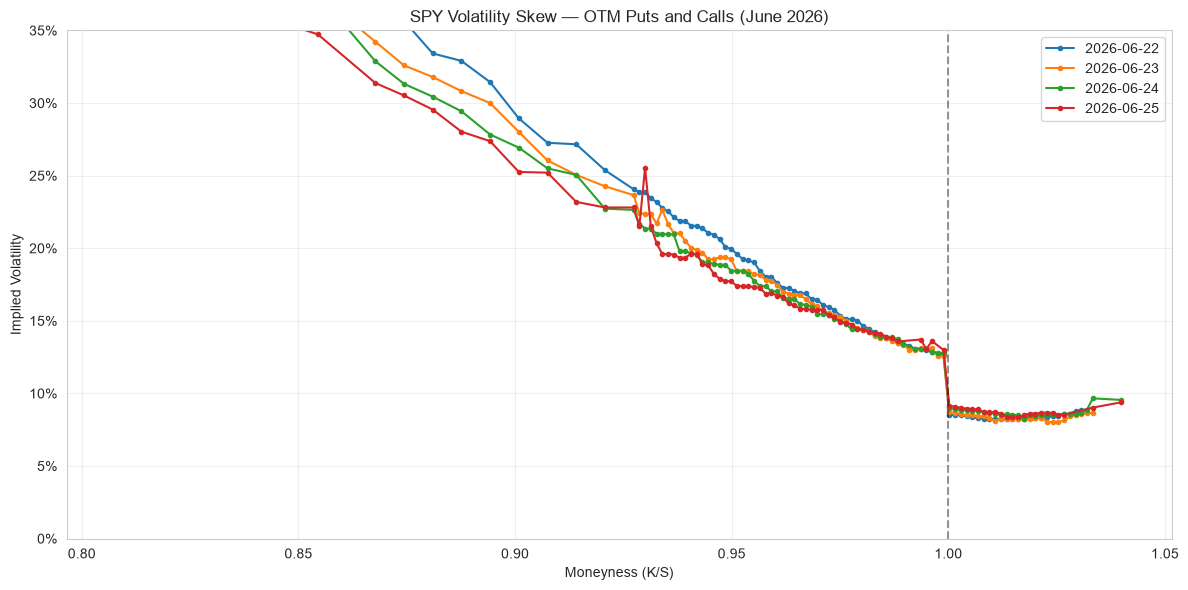

In [26]:
fig, ax = plt.subplots(figsize=(12, 6))

for exp in surface_df['expiry'].unique():
    subset = surface_df[surface_df['expiry'] == exp].copy()
    subset = subset.sort_values('moneyness')
    
    if len(subset) < 5:
        continue
        
    subset['iv_smooth'] = subset['iv'].rolling(3, center=True, min_periods=1).median()
    
    ax.plot(subset['moneyness'], subset['iv_smooth'], 
            marker='o', markersize=3, linewidth=1.5, label=str(exp))

ax.set_xlabel('Moneyness (K/S)')
ax.set_ylabel('Implied Volatility')
ax.set_title('SPY Volatility Skew — OTM Puts and Calls (June 2026)')
ax.legend()
ax.grid(True, alpha=0.3)
ax.set_ylim(0, 0.35)
ax.axvline(x=1.0, color='black', linestyle='--', alpha=0.4, label='ATM')
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'{y:.0%}'))
plt.tight_layout()
plt.show()

# Annotate OTM

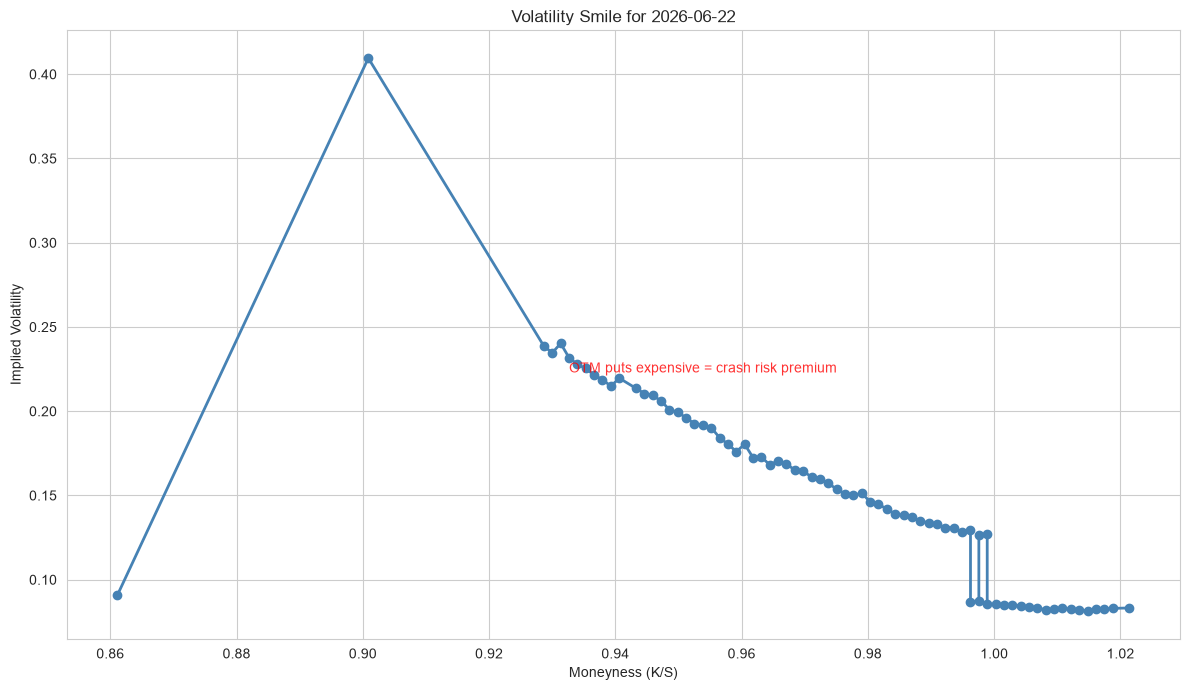

In [27]:
fig, ax = plt.subplots(figsize=(12, 7))

expiry_1 = expiries[0]
subset = liquid_df[liquid_df['expiry'] == expiry_1].copy()
if len(subset) > 0:
    subset = subset.sort_values('moneyness')
    ax.plot(subset['moneyness'], subset['iv'], marker='o', linewidth=2, color='steelblue')
    
    otm_puts = subset[subset['moneyness'] < 0.95]
    if len(otm_puts) > 0:
        ax.annotate('OTM puts expensive = crash risk premium',
                    xy=(otm_puts['moneyness'].mean(), otm_puts['iv'].mean()),
                    textcoords='data', color='red', fontsize=10, alpha=0.8)

ax.set_xlabel('Moneyness (K/S)')
ax.set_ylabel('Implied Volatility')
ax.set_title(f'Volatility Smile for {expiry_1}')
ax.grid(True)
plt.tight_layout()
plt.show()

# 3D Implied Volatility Surface

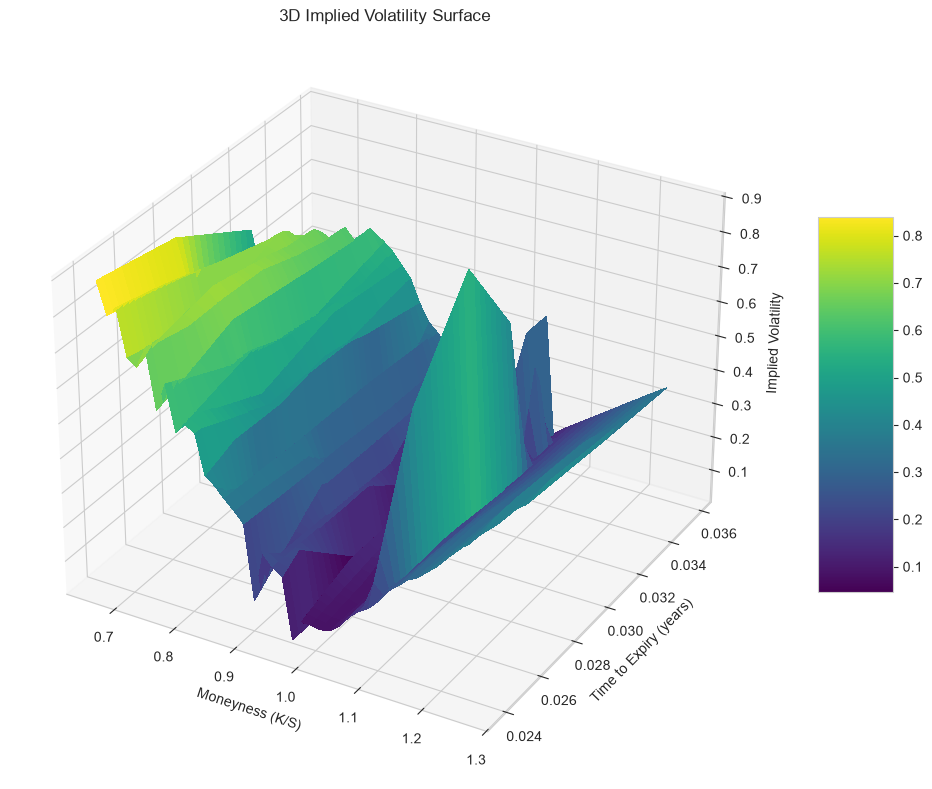


Volatility surface: IV as function of (moneyness, time to expiry)


In [20]:
X, Y, Z = iv_surface.plot_surface_data()

if X is not None:
    fig = plt.figure(figsize=(12, 8))
    ax = fig.add_subplot(111, projection='3d')
    surf = ax.plot_surface(X, Y, Z, cmap='viridis', linewidth=0, antialiased=False)
    ax.set_xlabel('Moneyness (K/S)')
    ax.set_ylabel('Time to Expiry (years)')
    ax.set_zlabel('Implied Volatility')
    ax.set_title('3D Implied Volatility Surface')
    fig.colorbar(surf, shrink=0.5, aspect=5)
    plt.tight_layout()
    plt.show()
    
    print("\nVolatility surface: IV as function of (moneyness, time to expiry)")
else:
    print("No surface data available")

# Most Liquid Options

In [21]:
liquid_top = liquid_df.sort_values('volume', ascending=False).head(10)
print("\nMost liquid options:")
liquid_top[['expiry', 'strike', 'moneyness', 'option_type', 'lastPrice', 'iv', 'volume']].to_string()


Most liquid options:


'         expiry  strike  moneyness option_type  lastPrice        iv  volume\n203  2026-06-22   745.0   0.986977         put       2.46  0.137368  9603.0\n61   2026-06-22   760.0   1.006849        call       1.99  0.083070  9068.0\n402  2026-06-23   724.0   0.959156         put       0.75  0.178233  6590.0\n56   2026-06-22   755.0   1.000225        call       4.15  0.085303  6392.0\n293  2026-06-23   767.0   1.016123        call       0.72  0.082720  6196.0\n407  2026-06-23   729.0   0.965780         put       0.99  0.167537  5880.0\n183  2026-06-22   725.0   0.960481         put       0.64  0.180422  4881.0\n205  2026-06-22   747.0   0.989627         put       2.88  0.133803  4426.0\n66   2026-06-22   765.0   1.013473        call       0.80  0.082041  4008.0\n54   2026-06-22   753.0   0.997576        call       5.35  0.087442  3942.0'

# Summary

In [22]:
print(f"\nSummary statistics for {ticker}:")
print(f"Spot price: {S:.2f}")
print(f"Number of liquid options: {liquid_df.shape[0]}")
print(f"IV range: {liquid_df['iv'].min():.3f} to {liquid_df['iv'].max():.3f}")
print(f"ATM IV (moneyness ~1.0): {liquid_df[liquid_df['moneyness'].between(0.98, 1.02)]['iv'].mean():.3f}")
print(f"OTM put IV (moneyness < 0.95): {liquid_df[liquid_df['moneyness'] < 0.95]['iv'].mean():.3f}")
print(f"OTM call IV (moneyness > 1.05): {liquid_df[liquid_df['moneyness'] > 1.05]['iv'].mean():.3f}")


Summary statistics for SPY:
Spot price: 754.83
Number of liquid options: 342
IV range: 0.057 to 0.926
ATM IV (moneyness ~1.0): 0.106
OTM put IV (moneyness < 0.95): 0.226
OTM call IV (moneyness > 1.05): 0.883
